In [1]:
# PREDICTIVE ANALYTICS FOR URBAN WATER DEMAND

# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix

# Load CSV File
df = pd.read_csv("urban_water_dataset.csv")


In [2]:
# Data Cleaning
# Fill missing values (if any)
df.fillna(df.mean(), inplace=True)

In [3]:
# Feature Selection
X = df[['Household_Size', 'Seasonal_Index', 'Garden_Area']]
y = df['Daily_Liters_Used']


In [4]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# Model Training
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
# Prediction
y_pred = model.predict(X_test_scaled)


In [8]:
# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
accuracy = r2*100
print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Accuracy :",accuracy,"%")


R2 Score: 0.9849937485128333
Mean Absolute Error: 14.387028894785088
Mean Squared Error: 287.2374770495383
Accuracy : 98.49937485128333 %


In [9]:
# Residual Analysis
residuals = y_test - y_pred
print(residuals)

361     7.466555
73    -30.654421
374    25.168911
155   -11.082485
104     2.911008
         ...    
347     6.351159
86      4.882532
75     -2.872350
438    25.203436
15      3.641381
Name: Daily_Liters_Used, Length: 100, dtype: float64


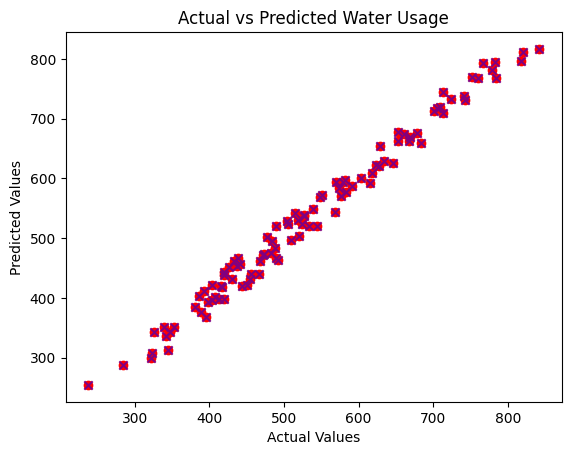

In [10]:
# Graphs
# 1. Actual vs Predicted
plt.figure()
# Actual Values
plt.scatter(y_test, y_pred,color = 'red',label="Actual Values",marker='o')
# Predicted Values
plt.scatter(y_test,y_pred,color='purple',label='Predicted Values',marker='x')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Water Usage")
plt.legend
plt.show()


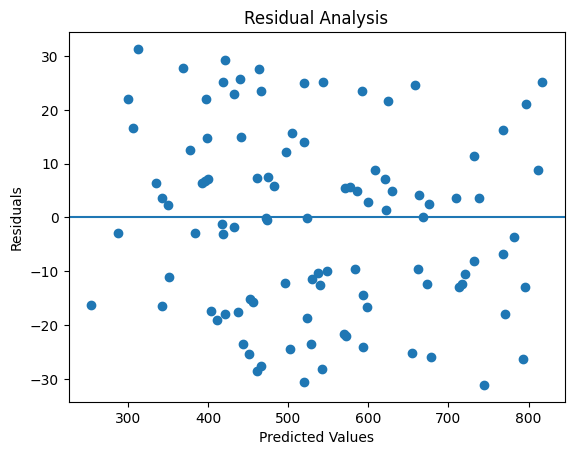

In [11]:
# 2. Residual Plot
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()


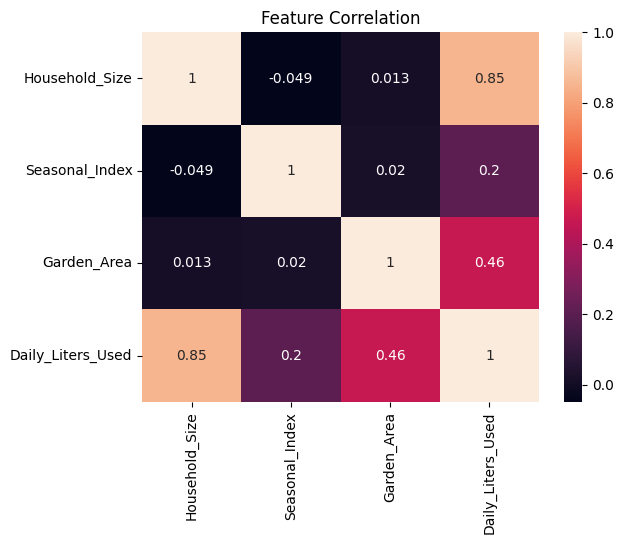

In [12]:
# 3. Heatmap (Correlation)
plt.figure()
sns.heatmap(df.corr(),annot=True)
plt.title("Feature Correlation")
plt.show()


In [13]:
# Confusion Matrix (Converted to Classification)
# Convert regression output to classification (High/Low usage)
threshold = df['Daily_Liters_Used'].mean()

y_test_class = [1 if val > threshold else 0 for val in y_test]
y_pred_class = [1 if val > threshold else 0 for val in y_pred]

cm = confusion_matrix(y_test_class, y_pred_class)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[52  3]
 [ 2 43]]
